<a href="https://colab.research.google.com/github/Abeer-Alsafran-ku/G-DINO/blob/main/Copy_of_grounding_dino_tiny.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# ------------------------------------------------
# SET UP
# ------------------------------------------------


In [ ]:
!pip install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 136.4 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.12.0
    Uninstalling transformers-5.12.0:
      Successfully uninstalled transformers-5.12.0


In [ ]:
import os
import json
import torch
from PIL import Image
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

# ----------------------------------------------------------------------------
# CONFIG
# ----------------------------------------------------------------------------
train_path = '/content/drive/MyDrive/Kdrone4/train'
test_path = '/content/drive/MyDrive/Kdrone4/test'
val_path = '/content/drive/MyDrive/Kdrone4/valid'

# VERY important: grounding dino text queries need to be lowercased + end with a dot
CATEGORY_NAMES = ["car", "bus", "truck", "pickup-truck", "van"]
TEXT_QUERY = " . ".join(CATEGORY_NAMES) + " ."

# Score threshold below which detections are discarded (None = keep everything
# the processor returns; tighten this if you get too many low-confidence boxes)
BOX_THRESHOLD = 0.25
TEXT_THRESHOLD = 0.25

# If you already have a ground-truth COCO json for the test set, point this at
# it. The script will then reuse its image_id / category_id numbering so the
# predictions line up exactly with the ground truth for your confusion matrix
# step. Leave as None to have the script invent its own ids from scratch.
GROUND_TRUTH_JSON = '/content/drive/MyDrive/Kdrone4/test/_annotations.coco.json'

OUTPUT_JSON = '/content/detected_objects_coco.json'

IMAGE_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')

# ----------------------------------------------------------------------------
# Dataset size sanity check (kept from original script)
# ----------------------------------------------------------------------------

In [ ]:
train = os.listdir(train_path)
test = os.listdir(test_path)
val = os.listdir(val_path)

print(f"Total = {len(train) + len(test) + len(val)}")
print(f"Train = {len(train)}")
print(f"Test = {len(test)}")
print(f"Val = {len(val)}")


Total = 5019
Train = 4381
Test = 421
Val = 217


# ----------------------------------------------------------------------------
# Load model
# ----------------------------------------------------------------------------

In [ ]:

device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoProcessor.from_pretrained("IDEA-Research/grounding-dino-tiny")
model = AutoModelForZeroShotObjectDetection.from_pretrained("IDEA-Research/grounding-dino-tiny")
model.to(device)
model.eval()


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.64k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/689M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/978 [00:00<?, ?it/s]

GroundingDinoForObjectDetection(
  (model): GroundingDinoModel(
    (backbone): GroundingDinoConvModel(
      (conv_encoder): GroundingDinoConvEncoder(
        (model): SwinBackbone(
          (swin): SwinModel(
            (embeddings): SwinEmbeddings(
              (patch_embeddings): SwinPatchEmbeddings(
                (projection): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
              )
              (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (encoder): SwinEncoder(
              (layers): ModuleList(
                (0): SwinStage(
                  (blocks): ModuleList(
                    (0): SwinLayer(
                      (attention): SwinAttention(
                        (q_proj): Linear(in_features=96, out_features=96, bias=True)
                        (k_proj): Linear(in_features=96, out_features=96, bias=True)
                        (v_proj): Linear(in_features

# ----------------------------------------------------------------------------
# Build the images list + category map
# ----------------------------------------------------------------------------

In [ ]:
test_files = sorted(f for f in os.listdir(test_path) if f.lower().endswith(IMAGE_EXTENSIONS))

if GROUND_TRUTH_JSON:
    with open(GROUND_TRUTH_JSON, 'r') as f:
        gt = json.load(f)

    # Reuse the ground truth's image ids (matched by file name) and categories,
    # so predictions and ground truth are directly comparable downstream.
    filename_to_image_id = {img['file_name']: img['id'] for img in gt['images']}
    categories = gt['categories']
    name_to_category_id = {c['name'].lower(): c['id'] for c in categories}

    images = []
    missing = []
    for fname in test_files:
        if fname in filename_to_image_id:
            images.append({'id': filename_to_image_id[fname], 'file_name': fname})
        else:
            missing.append(fname)
    if missing:
        print(f"Warning: {len(missing)} test images were not found in the ground "
              f"truth json and will be skipped (e.g. {missing[:3]})")
else:
    categories = [{'id': i + 1, 'name': name} for i, name in enumerate(CATEGORY_NAMES)]
    name_to_category_id = {c['name'].lower(): c['id'] for c in categories}
    images = [{'id': i + 1, 'file_name': fname} for i, fname in enumerate(test_files)]


def match_category_id(label_text):
    """Grounding DINO returns free-text phrase fragments, not exact category
    names, so match loosely against the known category names."""
    label = label_text.strip().lower()
    for name, cat_id in name_to_category_id.items():
        if name == label or name in label or label in name:
            return cat_id
    return None


# ----------------------------------------------------------------------------
# Run inference over every test image
# ----------------------------------------------------------------------------

In [ ]:
annotations = []
ann_id = 1
skipped = []

for idx, img_entry in enumerate(images, start=1):
    fname = img_entry['file_name']
    img_path = os.path.join(test_path, fname)

    try:
        image = Image.open(img_path).convert("RGB")
    except Exception as e:
        skipped.append(fname)
        print(f"[{idx}/{len(images)}] Could not open {fname}: {e}")
        continue

    inputs = processor(images=image, text=TEXT_QUERY, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)

    results = processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        threshold=BOX_THRESHOLD,
        text_threshold=TEXT_THRESHOLD,
        target_sizes=[image.size[::-1]],
    )
    prediction = results[0]

    for box, label, score in zip(prediction['boxes'], prediction['text_labels'], prediction['scores']):
        category_id = match_category_id(label)
        if category_id is None:
            # Detected phrase didn't match any of our known classes; skip it
            continue

        x_min, y_min, x_max, y_max = box.tolist()
        w = x_max - x_min
        h = y_max - y_min

        annotations.append({
            'id': ann_id,
            'image_id': img_entry['id'],
            'category_id': category_id,
            'bbox': [x_min, y_min, w, h],
            'area': w * h,
            'score': float(score.item()),
            'iscrowd': 0,
        })
        ann_id += 1

    if idx % 25 == 0 or idx == len(images):
        print(f"Processed {idx}/{len(images)} images, {len(annotations)} detections so far")

# ----------------------------------------------------------------------------
# Save COCO-format predictions
# ----------------------------------------------------------------------------
coco_predictions = {
    'images': images,
    'annotations': annotations,
    'categories': categories,
}

with open(OUTPUT_JSON, 'w') as f:
    json.dump(coco_predictions, f, indent=2)

print(f"\nSaved {len(annotations)} predicted boxes across {len(images)} images to {OUTPUT_JSON}")
if skipped:
    print(f"Skipped {len(skipped)} unreadable images: {skipped}")

# ----------------------------------------------------------------------------
# Quick look at the detections in tabular form
# ----------------------------------------------------------------------------
import pandas as pd

category_id_to_name = {c['id']: c['name'] for c in categories}
image_id_to_filename = {img['id']: img['file_name'] for img in images}

df_detections = pd.DataFrame([
    {
        'annotation_id': a['id'],
        'image_id': a['image_id'],
        'file_name': image_id_to_filename.get(a['image_id']),
        'category_id': a['category_id'],
        'label': category_id_to_name.get(a['category_id']),
        'score': a['score'],
        'bbox_xywh': a['bbox'],
    }
    for a in annotations
])

display(df_detections.head(20))

Processed 25/420 images, 81 detections so far
Processed 50/420 images, 220 detections so far
Processed 75/420 images, 303 detections so far
Processed 100/420 images, 417 detections so far
Processed 125/420 images, 479 detections so far
Processed 150/420 images, 810 detections so far
Processed 175/420 images, 1215 detections so far
Processed 200/420 images, 1455 detections so far
Processed 225/420 images, 1686 detections so far
Processed 250/420 images, 1934 detections so far
Processed 275/420 images, 2347 detections so far
Processed 300/420 images, 2450 detections so far
Processed 325/420 images, 2934 detections so far
Processed 350/420 images, 3256 detections so far
Processed 375/420 images, 3464 detections so far
Processed 400/420 images, 3759 detections so far
Processed 420/420 images, 3834 detections so far

Saved 3834 predicted boxes across 420 images to /content/detected_objects_coco.json


,annotation_id,image_id,file_name,category_id,label,score,bbox_xywh
0,1,38,20221016_436_Flight_02_01317_JPG.rf.5caa5888b2...,0,objects-person-car-bicycle--FwIE,0.417941,"[275.5611267089844, 579.5744018554688, 29.4915..."
1,2,38,20221016_436_Flight_02_01317_JPG.rf.5caa5888b2...,0,objects-person-car-bicycle--FwIE,0.394712,"[428.437255859375, 754.2301635742188, 28.07940..."
2,3,38,20221016_436_Flight_02_01317_JPG.rf.5caa5888b2...,2,car,0.362490,"[507.8518981933594, 858.644775390625, 31.84298..."
3,4,38,20221016_436_Flight_02_01317_JPG.rf.5caa5888b2...,0,objects-person-car-bicycle--FwIE,0.396430,"[363.91680908203125, 633.6526489257812, 29.445..."
4,5,38,20221016_436_Flight_02_01317_JPG.rf.5caa5888b2...,0,objects-person-car-bicycle--FwIE,0.398457,"[90.85857391357422, 412.5588684082031, 32.1566..."
5,6,38,20221016_436_Flight_02_01317_JPG.rf.5caa5888b2...,0,objects-person-car-bicycle--FwIE,0.419252,"[31.676876068115234, 363.8119201660156, 32.458..."
6,7,38,20221016_436_Flight_02_01317_JPG.rf.5caa5888b2...,2,car,0.367341,"[81.54454040527344, 356.872802734375, 32.03062..."
7,8,38,20221016_436_Flight_02_01317_JPG.rf.5caa5888b2...,2,car,0.356593,"[207.11912536621094, 508.542236328125, 32.0328..."
8,9,38,20221016_436_Flight_02_01317_JPG.rf.5caa5888b2...,1,bus,0.320625,"[158.15737915039062, 433.44635009765625, 31.77..."
9,10,38,20221016_436_Flight_02_01317_JPG.rf.5caa5888b2...,1,bus,0.325384,"[286.228515625, 549.2021484375, 28.69976806640..."


# ----------------------------------------------------------------------------
# Build the confusion matrix
# ----------------------------------------------------------------------------


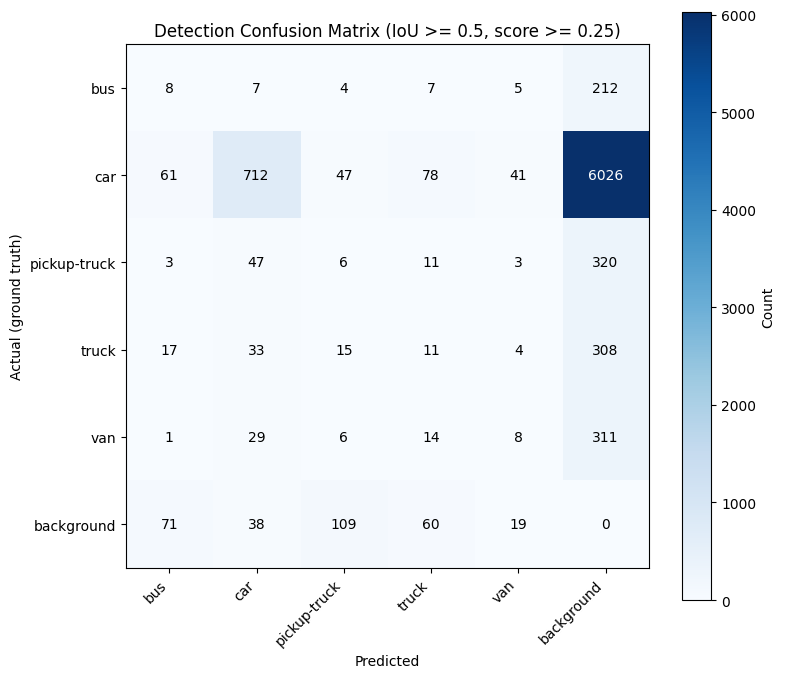

,bus,car,pickup-truck,truck,van,background
bus,8,7,4,7,5,212
car,61,712,47,78,41,6026
pickup-truck,3,47,6,11,3,320
truck,17,33,15,11,4,308
van,1,29,6,14,8,311
background,71,38,109,60,19,0


,class,tp,fp,fn,precision,recall
0,bus,8,153,235,0.049689,0.032922
1,car,712,154,6253,0.822171,0.102225
2,pickup-truck,6,181,384,0.032086,0.015385
3,truck,11,170,377,0.060773,0.028351
4,van,8,72,361,0.100000,0.021680


In [16]:
import json
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------------
# CONFIG
# ----------------------------------------------------------------------------
GROUND_TRUTH_JSON = '/content/drive/MyDrive/Kdrone4/test/_annotations.coco.json'
# PREDICTIONS_JSON = '/content/predictions/predictions_coco.json'
PREDICTIONS_JSON = '/content/drive/MyDrive/Kdrone4/predictions/grounding_dino_tiny/detected_objects_coco.json'

IOU_THRESHOLD = 0.5     # a prediction "matches" a GT box if IoU >= this
SCORE_THRESHOLD = 0.25  # predictions below this confidence are ignored

BACKGROUND_LABEL = "background"  # represents "missed" (false negative) / "spurious" (false positive)

# Class names to drop entirely (e.g. Roboflow adds an umbrella "objects-..."
# class at the top of the category tree that isn't a real detection target)
EXCLUDED_CLASSES = ["objects-person-car-bicycle--FwIE"]

# Roboflow exports often include a placeholder "super-category" (id 0) that
# just mirrors the dataset name rather than being a real object class.
# Anything listed here is dropped from categories and annotations.
EXCLUDED_CLASSES = ["objects-person-car-bicycle--FwIE"]

# ----------------------------------------------------------------------------
# Load data
# ----------------------------------------------------------------------------
with open(GROUND_TRUTH_JSON, 'r') as f:
    gt = json.load(f)

with open(PREDICTIONS_JSON, 'r') as f:
    pred = json.load(f)

# Category names, keyed by id (use ground truth as the source of truth for naming)
cat_id_to_name = {
    c['id']: c['name']
    for c in gt['categories']
    if c['name'] not in EXCLUDED_CLASSES
}
excluded_cat_ids = {c['id'] for c in gt['categories'] if c['name'] in EXCLUDED_CLASSES}

class_names = [cat_id_to_name[cid] for cid in sorted(cat_id_to_name)]
class_names_with_bg = class_names + [BACKGROUND_LABEL]
n_classes = len(class_names)

# Drop any GT/prediction boxes belonging to an excluded class entirely
gt['annotations'] = [a for a in gt['annotations'] if a['category_id'] not in excluded_cat_ids]
pred['annotations'] = [a for a in pred['annotations'] if a['category_id'] not in excluded_cat_ids]

# image_id -> list of {bbox (xyxy), category_id}
def group_by_image(annotations):
    by_image = {}
    for ann in annotations:
        x, y, w, h = ann['bbox']
        box = (x, y, x + w, y + h)
        by_image.setdefault(ann['image_id'], []).append({
            'box': box,
            'category_id': ann['category_id'],
            'score': ann.get('score', 1.0),
        })
    return by_image

gt_by_image = group_by_image(gt['annotations'])
pred_by_image = group_by_image(
    [a for a in pred['annotations'] if a.get('score', 1.0) >= SCORE_THRESHOLD]
)

all_image_ids = {img['id'] for img in gt['images']}


def iou(box_a, box_b):
    xa1, ya1, xa2, ya2 = box_a
    xb1, yb1, xb2, yb2 = box_b

    inter_x1 = max(xa1, xb1)
    inter_y1 = max(ya1, yb1)
    inter_x2 = min(xa2, xb2)
    inter_y2 = min(ya2, yb2)

    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = max(0.0, xa2 - xa1) * max(0.0, ya2 - ya1)
    area_b = max(0.0, xb2 - xb1) * max(0.0, yb2 - yb1)
    union = area_a + area_b - inter_area

    return inter_area / union if union > 0 else 0.0


# ----------------------------------------------------------------------------
# Build the confusion matrix
#
# Rows    = actual (ground truth) class, plus a "background" row for false
#           positives (a prediction that didn't match any GT box)
# Columns = predicted class, plus a "background" column for false negatives
#           (a GT box that no prediction matched)
# ----------------------------------------------------------------------------
matrix = np.zeros((n_classes + 1, n_classes + 1), dtype=int)
class_id_to_index = {cid: i for i, cid in enumerate(sorted(cat_id_to_name))}
BG_INDEX = n_classes

for image_id in all_image_ids:
    gts = gt_by_image.get(image_id, [])
    preds = pred_by_image.get(image_id, [])

    # Greedily match highest-confidence predictions first
    preds_sorted = sorted(preds, key=lambda d: d['score'], reverse=True)
    matched_gt_indices = set()

    for p in preds_sorted:
        best_iou = 0.0
        best_gt_idx = -1
        for gi, g in enumerate(gts):
            if gi in matched_gt_indices:
                continue
            cur_iou = iou(p['box'], g['box'])
            if cur_iou > best_iou:
                best_iou = cur_iou
                best_gt_idx = gi

        pred_idx = class_id_to_index[p['category_id']]

        if best_iou >= IOU_THRESHOLD and best_gt_idx != -1:
            matched_gt_indices.add(best_gt_idx)
            gt_idx = class_id_to_index[gts[best_gt_idx]['category_id']]
            matrix[gt_idx, pred_idx] += 1
        else:
            # Prediction with no matching GT box -> false positive
            matrix[BG_INDEX, pred_idx] += 1

    # Any GT boxes nobody matched -> false negative (missed detection)
    for gi, g in enumerate(gts):
        if gi not in matched_gt_indices:
            gt_idx = class_id_to_index[g['category_id']]
            matrix[gt_idx, BG_INDEX] += 1

# matrix[BACKGROUND, BACKGROUND] is meaningless (never incremented) -> leave at 0

# ----------------------------------------------------------------------------
# Plot
# ----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(matrix, cmap='Blues')

ax.set_xticks(range(len(class_names_with_bg)))
ax.set_yticks(range(len(class_names_with_bg)))
ax.set_xticklabels(class_names_with_bg, rotation=45, ha='right')
ax.set_yticklabels(class_names_with_bg)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual (ground truth)')
ax.set_title(f'Detection Confusion Matrix (IoU >= {IOU_THRESHOLD}, score >= {SCORE_THRESHOLD})')

# Annotate each cell with its count
max_val = matrix.max() if matrix.max() > 0 else 1
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        value = matrix[i, j]
        ax.text(j, i, str(value), ha='center', va='center',
                color='white' if value > max_val / 2 else 'black')

fig.colorbar(im, ax=ax, label='Count')
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# Also show it as a labeled DataFrame, and per-class precision/recall
# ----------------------------------------------------------------------------
import pandas as pd

df_cm = pd.DataFrame(matrix, index=class_names_with_bg, columns=class_names_with_bg)
display(df_cm)

rows = []
for i, name in enumerate(class_names):
    tp = matrix[i, i]
    fp = matrix[:, i].sum() - tp   # predicted as this class but wasn't (incl. background row)
    fn = matrix[i, :].sum() - tp   # was this class but predicted as something else (incl. background col)
    precision = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
    recall = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
    rows.append({'class': name, 'tp': tp, 'fp': fp, 'fn': fn, 'precision': precision, 'recall': recall})

df_metrics = pd.DataFrame(rows)
display(df_metrics)

# ----------------------------------------------
# TRAIN
# ----------------------------------------------

In [2]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from PIL import Image
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
from pycocotools.coco import COCO


import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"



# =====================================================================
# 1. DATASET DEFINITION
# =====================================================================

class COCOGroundingDinoDataset(Dataset):
    def __init__(self, img_dir, ann_file, processor):
        """
        Custom Dataset for formatting COCO annotations for Grounding DINO.
        """
        self.img_dir = img_dir
        self.coco = COCO(ann_file)
        self.ids = list(self.coco.imgs.keys())
        self.processor = processor

        # Define target classes
        self.categories = ["car", "bus", "truck", "pickup-truck", "van"]
        self.cat_id_to_name = {cat_id: cat['name'] for cat_id, cat in self.coco.cats.items()}

        # Grounding DINO global prompt text
        self.text_prompt = " . ".join(self.categories) + " ."

    def __len__(self):
        return len(self.ids)

    def _coco_to_xywhn(self, bbox, img_w, img_h):
        """Converts COCO [xmin, ymin, w, h] to normalized [cx, cy, w, h]"""
        xmin, ymin, w, h = bbox

        cx = xmin + (w / 2.0)
        cy = ymin + (h / 2.0)

        # Normalize between [0, 1]
        cx /= img_w
        cy /= img_h
        w /= img_w
        h /= img_h

        return [cx, cy, w, h]

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)

        # Load image
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.img_dir, img_info['file_name'])
        image = Image.open(img_path).convert("RGB")
        img_w, img_h = image.size

        boxes = []
        class_labels = []

        for ann in anns:
            cat_name = self.cat_id_to_name.get(ann['category_id'])

            # Filter for our specific classes and ensure valid bounding box dimensions
            if cat_name in self.categories and ann['bbox'][2] > 0 and ann['bbox'][3] > 0:
                norm_box = self._coco_to_xywhn(ann['bbox'], img_w, img_h)
                boxes.append(norm_box)

                class_idx = self.categories.index(cat_name)
                class_labels.append(class_idx)

        # Handle images with no target objects
        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            class_labels = torch.zeros((0,), dtype=torch.long)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            class_labels = torch.tensor(class_labels, dtype=torch.long)

        # Process image and text
        inputs = self.processor(images=image, text=self.text_prompt, return_tensors="pt")

        # Remove batch dimension added by processor
        inputs = {k: v.squeeze(0) for k, v in inputs.items()}

        inputs["labels"] = {
            "boxes": boxes,
            "class_labels": class_labels
        }

        return inputs


def collate_fn(batch):
    """Custom collate function to handle variable number of objects per image."""
    batch_dict = {}
    for key in batch[0].keys():
        if key == "labels":
            batch_dict[key] = [d[key] for d in batch]
        else:
            batch_dict[key] = torch.stack([d[key] for d in batch])
    return batch_dict


# =====================================================================
# 2. MAIN TRAINING CONFIGURATION AND LOOP
# =====================================================================

def main():
    # Paths config - REPLACE THESE WITH YOUR ACTUAL PATHS
    TRAIN_IMG_DIR = "/content/drive/MyDrive/Kdrone4/train"
    TRAIN_ANN_FILE = "/content/drive/MyDrive/Kdrone4/train/_annotations.coco.json"

    VAL_IMG_DIR = "/content/drive/MyDrive/Kdrone4/valid"
    VAL_ANN_FILE = "/content/drive/MyDrive/Kdrone4/valid/_annotations.coco.json"

    BATCH_SIZE = 4
    NUM_EPOCHS = 50
    LEARNING_RATE = 2e-5
    OUTPUT_DIR = "./fine-tuned-grounding-dino"

    # Set up device
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # Load Model & Processor
    model_id = "IDEA-Research/grounding-dino-tiny"
    processor = AutoProcessor.from_pretrained(model_id)
    model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id)
    model.to(device)

    # Instantiate Datasets & DataLoaders
    train_dataset = COCOGroundingDinoDataset(TRAIN_IMG_DIR, TRAIN_ANN_FILE, processor)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

    # Optimizer
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

    print("Starting fine-tuning...")
    for epoch in range(NUM_EPOCHS):
        model.train()
        epoch_loss = 0

        for batch_idx, batch in enumerate(train_loader):
            optimizer.zero_grad()

            # Prepare inputs
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            pixel_values = batch["pixel_values"].to(device)

            # Prepare targets
            labels = [{k: v.to(device) for k, v in target.items()} for target in batch["labels"]]

            # Forward pass
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                pixel_values=pixel_values,
                labels=labels
            )

            loss = outputs.loss

            # Backward pass
            loss.backward()

            # Clip gradients to stabilize training
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)

            optimizer.step()

            epoch_loss += loss.item()

            if batch_idx % 10 == 0:
                print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Step [{batch_idx}/{len(train_loader)}] | Loss: {loss.item():.4f}")

        print(f"--- Epoch {epoch+1} Completed. Average Loss: {epoch_loss / len(train_loader):.4f} ---")

    # Save fine-tuned model and processor
    print(f"Saving model checkpoints to {OUTPUT_DIR}...")
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    model.save_pretrained(OUTPUT_DIR)
    processor.save_pretrained(OUTPUT_DIR)
    print("Fine-tuning finished successfully!")

if __name__ == "__main__":
    main()

Using device: cuda


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.64k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/689M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/978 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
Epoch [5/50] | Step [1070/1095] | Loss: 2.5502
Epoch [5/50] | Step [1080/1095] | Loss: 2.5592
Epoch [5/50] | Step [1090/1095] | Loss: 2.4435
--- Epoch 5 Completed. Average Loss: 2.5056 ---
Epoch [6/50] | Step [0/1095] | Loss: 2.2995
Epoch [6/50] | Step [10/1095] | Loss: 2.1768
Epoch [6/50] | Step [20/1095] | Loss: 2.6535
Epoch [6/50] | Step [30/1095] | Loss: 2.1764
Epoch [6/50] | Step [40/1095] | Loss: 2.2239
Epoch [6/50] | Step [50/1095] | Loss: 2.5019
Epoch [6/50] | Step [60/1095] | Loss: 2.3047
Epoch [6/50] | Step [70/1095] | Loss: 2.5587
Epoch [6/50] | Step [80/1095] | Loss: 2.5059
Epoch [6/50] | Step [90/1095] | Loss: 2.6687
Epoch [6/50] | Step [100/1095] | Loss: 2.4754
Epoch [6/50] | Step [110/1095] | Loss: 2.1550
Epoch [6/50] | Step [120/1095] | Loss: 2.9513
Epoch [6/50] | Step [130/1095] | Loss: 2.4481
Epoch [6/50] | Step [140/1095] | Loss: 2.2868
Epoch [6/50] | Step [150/1095] | Loss: 3.1883
Epoch [6/50] | Step [160/1095] | Lo

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuning finished successfully!


#------------------------------------------
# Inference on fine-tuned model
#------------------------------------------

In [11]:
import os
import json
import torch
from PIL import Image, ImageDraw, ImageFont
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

# ----------------------------------------------------------------------------
# CONFIG
# ----------------------------------------------------------------------------
IMAGE_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')
CHECKPOINT_DIR = "./fine-tuned-grounding-dino"
TEST_IMAGE_PATH = "/content/drive/MyDrive/Kdrone4/test"
OUTPUT_DIR = "./predictions"
BOX_THRESHOLD = 0.25

# Point this at the test split's ground-truth COCO json so the predictions
# json reuses the exact same image_ids and category_ids (matched by file
# name) -- this is what makes the two jsons directly comparable later (e.g.
# for the confusion matrix).
GROUND_TRUTH_JSON = "/content/drive/MyDrive/Kdrone4/test/_annotations.coco.json"
PREDICTIONS_JSON = os.path.join(OUTPUT_DIR, "predictions_coco.json")

# Classes to ignore entirely (e.g. Roboflow's umbrella "objects-..."
# super-category, which isn't a real detection target)
EXCLUDED_CLASSES = ["objects-person-car-bicycle--FwIE"]

SAVE_VISUALIZATIONS = False  # set False to skip drawing/saving annotated images


def load_model(checkpoint_dir, device):
    """Loads the fine-tuned model and processor from your saved directory."""
    print(f"Loading fine-tuned model from {checkpoint_dir}...")
    processor = AutoProcessor.from_pretrained(checkpoint_dir)
    model = AutoModelForZeroShotObjectDetection.from_pretrained(checkpoint_dir)
    model.to(device)
    model.eval()
    return processor, model


def run_inference(image_path, text_prompt, processor, model, device, threshold=0.3):
    """Runs inference on a single image and returns filtered detections."""
    image = Image.open(image_path).convert("RGB")

    inputs = processor(images=image, text=text_prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    target_sizes = torch.tensor([image.size[::-1]], device=device)

    results = processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        threshold=threshold,
        text_threshold=threshold,
        target_sizes=target_sizes,
    )[0]

    return image, results


def visualize_predictions(image, results, output_path):
    """Draws bounding boxes and labels on the image and saves it."""
    image = image.copy()
    draw = ImageDraw.Draw(image)

    try:
        font = ImageFont.load_default()
    except IOError:
        font = None

    scores = results["scores"].cpu().numpy()
    boxes = results["boxes"].cpu().numpy()
    labels = results["text_labels"] if "text_labels" in results else results["labels"]

    for score, box, label in zip(scores, boxes, labels):
        xmin, ymin, xmax, ymax = box
        draw.rectangle([xmin, ymin, xmax, ymax], outline="red", width=3)
        text = f"{label}: {score:.2f}"
        draw.text((xmin + 2, ymin + 2), text, fill="red", font=font)

    image.save(output_path)
    print(f"Saved prediction visualization to {output_path}")


def build_category_lookup(ground_truth_json, excluded_classes):
    """Loads categories from the ground truth json (excluding unwanted
    classes) and builds image_id/category_id lookups so predictions line
    up exactly with the ground truth."""
    with open(ground_truth_json, 'r') as f:
        gt = json.load(f)

    categories = [c for c in gt['categories'] if c['name'] not in excluded_classes]
    name_to_category_id = {c['name'].lower(): c['id'] for c in categories}
    filename_to_image_id = {img['file_name']: img['id'] for img in gt['images']}

    return categories, name_to_category_id, filename_to_image_id


def match_category_id(label_text, name_to_category_id):
    """Grounding DINO returns free-text phrase fragments, not necessarily
    exact category names, so try an exact match first and fall back to
    substring matching."""
    label = label_text.strip().lower()
    if label in name_to_category_id:
        return name_to_category_id[label]
    for name, cat_id in name_to_category_id.items():
        if name in label or label in name:
            return cat_id
    return None


def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    test_image_files = sorted(
        f for f in os.listdir(TEST_IMAGE_PATH) if f.lower().endswith(IMAGE_EXTENSIONS)
    )
    print(f"Found {len(test_image_files)} image files in '{TEST_IMAGE_PATH}'")

    categories, name_to_category_id, filename_to_image_id = build_category_lookup(
        GROUND_TRUTH_JSON, EXCLUDED_CLASSES
    )
    text_prompt = " . ".join(c['name'].lower() for c in categories) + " ."
    print(f"Text prompt: {text_prompt}")

    device = "cuda" if torch.cuda.is_available() else "cpu"

    if not os.path.exists(CHECKPOINT_DIR):
        print(f"Error: Checkpoint directory '{CHECKPOINT_DIR}' not found.")
        return

    processor, model = load_model(CHECKPOINT_DIR, device)

    images_out = []
    annotations_out = []
    ann_id = 1
    skipped = []

    for idx, image_file in enumerate(test_image_files, start=1):
        full_image_path = os.path.join(TEST_IMAGE_PATH, image_file)
        output_image_path = os.path.join(OUTPUT_DIR, f"pred_{image_file}")

        # Reuse the ground truth's image_id when this file is in it, so the
        # predictions json is directly comparable to ground truth.
        image_id = filename_to_image_id.get(image_file)
        if image_id is None:
            skipped.append(image_file)
            print(f"[{idx}/{len(test_image_files)}] '{image_file}' not found in "
                  f"ground truth json -- skipping.")
            continue

        print(f"\n--- Predicting on: {image_file} ({idx}/{len(test_image_files)}) ---")

        try:
            image, results = run_inference(
                full_image_path, text_prompt, processor, model, device, threshold=BOX_THRESHOLD
            )
        except Exception as e:
            print(f"Failed to process {image_file}. Error: {e}")
            continue

        images_out.append({'id': image_id, 'file_name': image_file})

        text_labels = results["text_labels"] if "text_labels" in results else results["labels"]
        print(f"Detected {len(results['scores'])} objects:")

        for score, box, label in zip(results["scores"], results["boxes"], text_labels):
            box_list = [round(v, 2) for v in box.tolist()]
            print(f" - Class: '{label}', Confidence: {score:.2f}, Box: {box_list}")

            category_id = match_category_id(label, name_to_category_id)
            if category_id is None:
                continue  # detected phrase didn't match any known class

            x_min, y_min, x_max, y_max = box.tolist()
            w = x_max - x_min
            h = y_max - y_min

            annotations_out.append({
                'id': ann_id,
                'image_id': image_id,
                'category_id': category_id,
                'bbox': [x_min, y_min, w, h],
                'area': w * h,
                'score': float(score.item()),
                'iscrowd': 0,
            })
            ann_id += 1

        if SAVE_VISUALIZATIONS:
            visualize_predictions(image, results, output_image_path)

    coco_predictions = {
        'images': images_out,
        'annotations': annotations_out,
        'categories': categories,
    }

    with open(PREDICTIONS_JSON, 'w') as f:
        json.dump(coco_predictions, f, indent=2)

    print(f"\nSaved {len(annotations_out)} predicted boxes across {len(images_out)} "
          f"images to {PREDICTIONS_JSON}")
    if skipped:
        print(f"Skipped {len(skipped)} images not present in ground truth json: {skipped}")


if __name__ == "__main__":
    main()

Found 420 image files in '/content/drive/MyDrive/Kdrone4/test'
Text prompt: bus . car . pickup-truck . truck . van .
Loading fine-tuned model from ./fine-tuned-grounding-dino...


Loading weights:   0%|          | 0/980 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
 - Class: 'car', Confidence: 0.91, Box: [95.34, 526.26, 114.62, 578.24]

--- Predicting on: Flight_03_part1_mp4-0019_jpg.rf.e627b184a4d5d9ec729cc05099151fdb.jpg (243/420) ---
Detected 14 objects:
 - Class: 'car', Confidence: 0.93, Box: [662.45, 126.77, 679.75, 173.39]
 - Class: 'truck', Confidence: 0.93, Box: [585.61, 22.66, 617.48, 102.06]
 - Class: 'car', Confidence: 0.95, Box: [716.47, 546.87, 734.57, 593.85]
 - Class: 'car', Confidence: 0.85, Box: [798.85, 815.61, 817.09, 853.01]
 - Class: 'car', Confidence: 0.87, Box: [477.41, 267.92, 495.75, 316.15]
 - Class: 'car', Confidence: 0.94, Box: [684.9, 455.5, 701.54, 494.86]
 - Class: 'car', Confidence: 0.58, Box: [617.42, 61.18, 635.64, 106.71]
 - Class: 'car', Confidence: 0.86, Box: [449.06, 247.4, 466.38, 292.19]
 - Class: 'car', Confidence: 0.89, Box: [677.04, 562.91, 692.91, 607.24]
 - Class: 'car', Confidence: 0.90, Box: [841.71, 673.87, 860.52, 720.92]
 - Class: 'car', Confidenc

Results of grounding dino with out fine tuning are in
PREDICTIONS_JSON = '/content/drive/MyDrive/Kdrone4/predictions/grounding_dino_tiny/detected_objects_coco.json'

Results of fine tuned model are in
PREDICTIONS_JSON = '/content/drive/MyDrive/fine-tuned-grounding-dino/predictions/predictions_coco.json'

